In [1]:
import sys
from pathlib import Path
import os
import pandas as pd
sys.path.append(str(Path.cwd().parent))
DATA_DIR = os.path.join(os.getcwd(), "..", "data")

In [ ]:
from src.load_data import get_moex_candles, save_candles_df
from datetime import datetime
start_date = datetime(2013, 1, 1)
end_date = datetime(2026, 3, 15)
ticker = "IMOEX"

candles = get_moex_candles(ticker, start_date, end_date, rest_time=0.5, interval=10, market="index")
save_candles_df(candles, "IMOEX.csv")

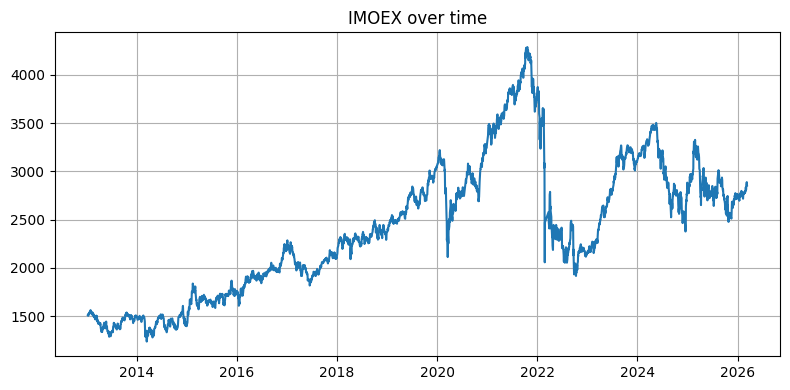

In [3]:
candles = pd.read_csv(os.path.join(DATA_DIR, "IMOEX.csv"))
candles['end'] = pd.to_datetime(candles['end'])
candles.set_index('end', inplace=True)
candles = candles.resample("D").agg({
    'open': 'first',
    'high': 'max',
    'low': 'min',
    'close': 'last',
    'volume': 'sum'  
}).dropna()

from matplotlib import pyplot as plt
plt.figure(figsize=(8, 4))
plt.plot(candles.index, candles['close'])
plt.title("IMOEX over time")
plt.grid()
plt.tight_layout()

In [4]:
from src.get_features import add_log_returns, add_volatility

candles = add_log_returns(candles, [1, 7, 14, 30, 90])
candles = add_volatility(candles, [7, 14, 30, 90])

Model is not converging.  Current: 81919.6405151958 is not greater than 81919.64201262391. Delta is -0.0014974281075410545
Model is not converging.  Current: 84382.73394669675 is not greater than 84382.85416615734. Delta is -0.12021946058666799
Model is not converging.  Current: 84713.61950465609 is not greater than 84713.8342648857. Delta is -0.21476022961724084
Model is not converging.  Current: 84617.72614115858 is not greater than 84617.72677768592. Delta is -0.0006365273438859731
Model is not converging.  Current: 84899.10799179175 is not greater than 85082.58875847199. Delta is -183.48076668023714
Model is not converging.  Current: 84644.08424066873 is not greater than 84704.8413761379. Delta is -60.75713546917541
Model is not converging.  Current: 84875.0946539832 is not greater than 84875.09692206411. Delta is -0.002268080919748172
Model is not converging.  Current: 84590.35457357367 is not greater than 84627.51644884302. Delta is -37.16187526934664
Model is not converging.  Cu

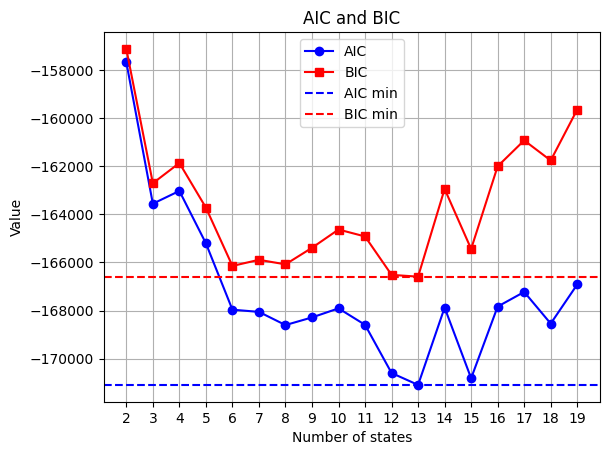

In [5]:
from src.train_hmm import train_hmm
features = [
    "log_returns_7", "log_returns_14", "log_returns_30", "log_returns_90",
    "volatility_7", "volatility_14", "volatility_30", "volatility_90"
]

candles = candles.dropna()
X = candles[features].values

bics = []
aics = []
ks = range(2, 20)
for k in ks:
    model = train_hmm(X, n_states=k, n_iter=5000)
    bics.append(model.bic(X))
    aics.append(model.aic(X))

plt.plot(ks, aics, marker='o', label='AIC', color='blue')
plt.plot(ks, bics, marker='s', label='BIC', color='red')

min_aic = min(aics)
min_bic = min(bics)
plt.axhline(min_aic, linestyle='--', label='AIC min', color='blue')
plt.axhline(min_bic, linestyle='--', label='BIC min', color='red')

plt.xlabel('Number of states')
plt.ylabel('Value')
plt.title('AIC and BIC')
plt.grid()
plt.xticks(ks)
plt.legend()
plt.show()

In [13]:
model = train_hmm(X, n_states=3, n_iter=5000)

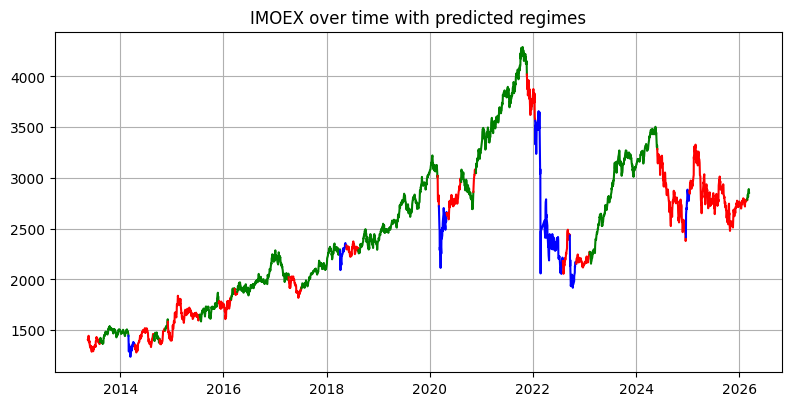

In [14]:
from src.visualization import plot_price_with_regimes
regimes = model.predict(X)
dates = candles.index
prices = candles['close'].values

plot_price_with_regimes(prices, dates, regimes)

In [15]:
candles['regime'] = regimes
statistics = candles.groupby('regime').agg({
    'log_returns_7': ['mean', 'std'],
    'volatility_7': ['mean', 'std'],
    'close':['count']
})

print(statistics)

       log_returns_7           volatility_7           close
                mean       std         mean       std count
regime                                                     
0           0.005612  0.022723     0.007986  0.003032  1779
1          -0.000533  0.036995     0.012135  0.005123  1180
2          -0.017038  0.093090     0.027970  0.027538   261


[[9.93673004e-001 5.20113454e-003 1.12586127e-003]
 [1.02909074e-002 9.86325815e-001 3.38327767e-003]
 [1.78771616e-235 2.30487423e-002 9.76951258e-001]]


Text(50.722222222222214, 0.5, 'from')

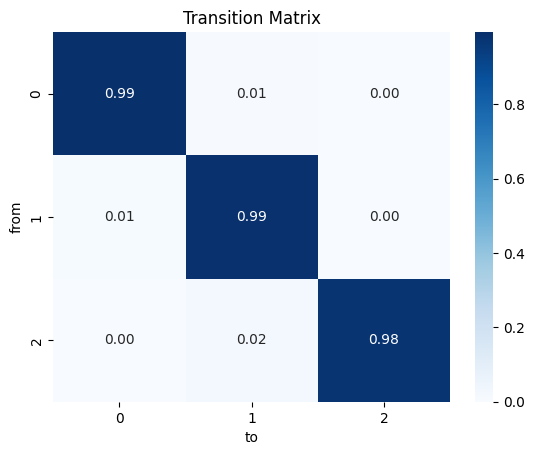

In [16]:
import seaborn as sns
sns.heatmap(model.transmat_, annot=True, cmap="Blues", fmt=".2f")
print(model.transmat_)
plt.title("Transition Matrix")
plt.xlabel("to")
plt.ylabel("from")

In [17]:
import numpy as np
trans = model.transmat_
expected_duration = 1 / (1 - np.diag(trans))
df = pd.DataFrame({
    "Stay Probability": np.diag(trans),
    "Expected regime duration (days)": np.round(expected_duration, 2)
})
print(df)

   Stay Probability  Expected regime duration (days)
0          0.993673                           158.05
1          0.986326                            73.13
2          0.976951                            43.39
